# Week 2 · Linear Regression Baseline
Business Rehearsal Outcome Predictor · Spring 2026

Ridge regression baseline — one model per target, temporal 80/20 split.
Sets the performance floor that XGBoost (Week 3) must beat.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.spines.top': False, 'axes.spines.right': False})
from models.baseline import (
    load_features, temporal_split, train_baseline,
    print_results, top_features, CONFIDENCE_Z
)


In [2]:
df = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)
results = train_baseline(train, test)
print_results(results)


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423

Target                        MAPE    Calibration (80% CI)
───────────────────────────────────────────────────────────
  Inventory Delta         320.4%    0.89  (target: 0.80)
  Cash Flow Delta         134.7%    0.91  (target: 0.80)
  Order Velocity Delta    127.8%    0.82  (target: 0.80)

Interpretation guide:
  MAPE < 15%   → strong baseline
  MAPE 15-30%  → acceptable, useful for a founder
  MAPE > 30%   → weak — XGBoost should beat this comfortably

  Calibration near 0.80 → prediction intervals are honest
  Calibration >> 0.80   → intervals too wide
  Calibration << 0.80   → intervals too narrow


In [3]:
top_features(results)



Top features per target (Ridge |coefficient|):

  inventory:
    mag_restock_qty_norm                           +121.7481
    mag_new_skus                                   +29.4768
    mag_discount_pct                               -12.1005
    bt_markdown                                    -9.0504
    bt_bulk_restock                                -7.7591
    history_depth_days                             +7.6224
    month_cos                                      +7.4759
    bt_volume_discount                             +7.1008
    w90_restock_count                              -6.1752
    w90_weighted_order_count                       -5.4155

  cashflow:
    mag_restock_cost_norm                          -6455.6852
    bt_markdown                                    -1816.4421
    mag_contract_norm                              +1449.7957
    bt_price_increase                              +1405.4801
    bt_promo_event                                 +1113.5721
    w7_weighted_order

## Predicted vs actual
Points on the diagonal = perfect prediction. Red dashed line is y = x.

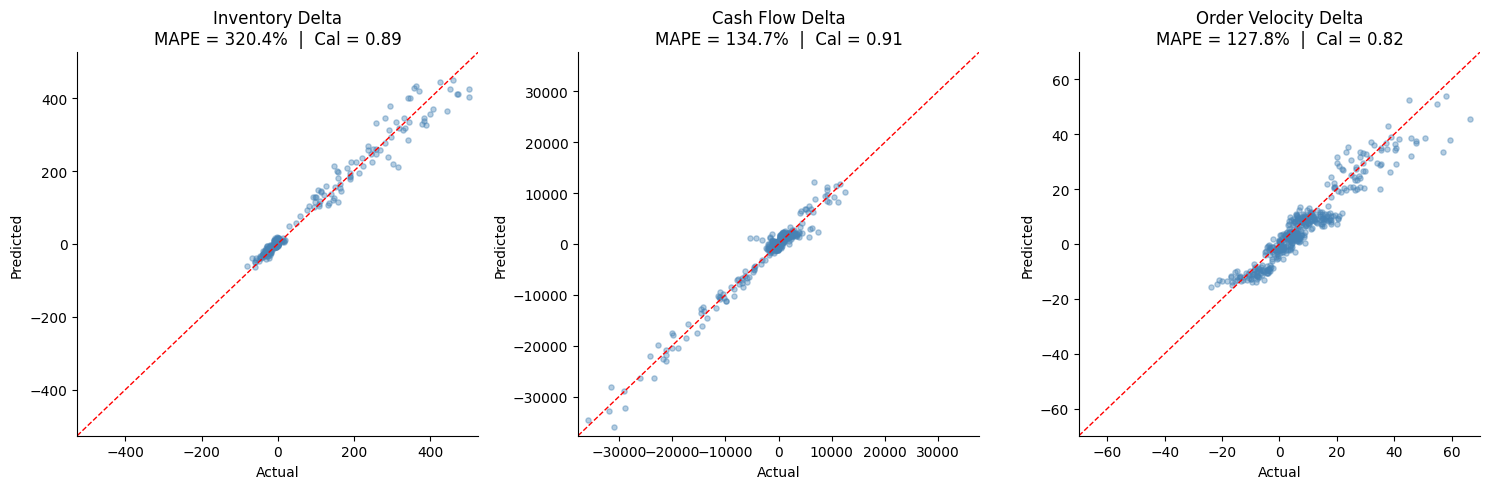

In [4]:
labels = {
    'label_inventory_delta':      'Inventory Delta',
    'label_cashflow_delta':       'Cash Flow Delta',
    'label_order_velocity_delta': 'Order Velocity Delta',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (target, r) in zip(axes, results.items()):
    ax.scatter(r['y_test'], r['y_pred'], alpha=0.4, s=14, color='steelblue')
    lim = max(np.abs(r['y_test']).max(), np.abs(r['y_pred']).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f"{labels[target]}\nMAPE = {r['mape']:.1f}%  |  Cal = {r['calibration']:.2f}")
plt.tight_layout()
plt.show()


## Prediction intervals — sample of 60 test points
Bars show the 80% CI (point ± 1.28 σ). Points outside the bar = miscalibrated.

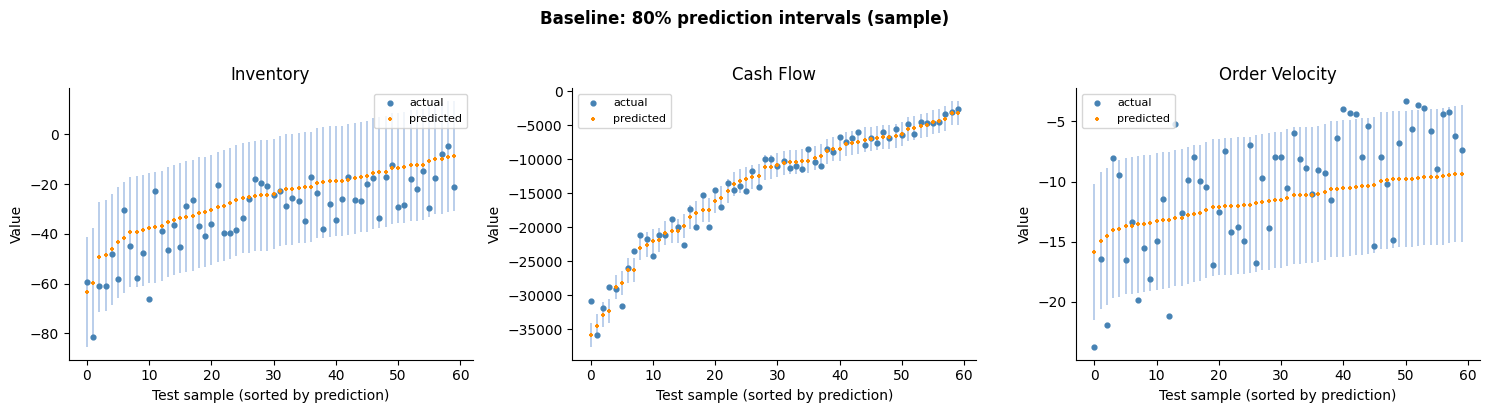

In [5]:
N = 60
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (target, r) in zip(axes, results.items()):
    idx    = np.argsort(r['y_pred'])[:N]
    pred   = r['y_pred'][idx]
    actual = r['y_test'][idx]
    half   = CONFIDENCE_Z * r['resid_std']
    ax.errorbar(range(N), pred, yerr=half, fmt='none',
                ecolor='#aec6e8', elinewidth=1.2, capsize=0)
    ax.scatter(range(N), actual, s=12, color='steelblue', zorder=3, label='actual')
    ax.scatter(range(N), pred,   s=12, color='darkorange', zorder=3,
               label='predicted', marker='+')
    ax.set_xlabel('Test sample (sorted by prediction)')
    ax.set_ylabel('Value')
    ax.set_title(labels[target].replace(' Delta', ''))
    ax.legend(fontsize=8)
plt.suptitle('Baseline: 80% prediction intervals (sample)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
